# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zoro-369/flyrank-ml-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Abstract

This capstone asks whether information available before a decision date can rank content pages that are likely to experience a meaningful 30-day future decline. Using the pseudonymized FlyRank warehouse, I aggregate a 90-day pre-decision feature window and define decline from the following 30-day impression change. I compare a transparent stale-and-visible baseline with Logistic Regression and Random Forest models using leakage checks, a future validation period, an unseen-client validation audit, and a sealed May 2026 test period. On the sealed May test, the final Random Forest achieved Precision@20 of 0.95, Precision@50 of 0.98, average precision of 0.852, and ROC-AUC of 0.751, compared with 0.95, 0.96, 0.675, and 0.500 for the baseline. The final output is a ranked, human-review queue with risk scores, reason codes, and action labels; it is intended as observational decision-support rather than causal evidence about search performance or refresh impact.

## 1. Question

### Research question

> **Can information available before a decision date be used to rank pages that are likely to experience a meaningful future decline, so a content team can review the highest-risk pages first?**

### Decision

Which pages should be reviewed first when editorial capacity is limited?

### Unit of analysis

One row represents **one content page at one decision date**.

### Output

A decline-risk score, rank, reason code, action label, and priority band label.

### Human action

A reviewer uses the queue to prioritize investigation for refresh, improvement, protection, consolidation/pruning review, or monitoring.

### Cost of a wrong call

A false positive spends limited editorial capacity on a page that did not experience the defined decline. A false negative leaves a genuinely declining page lower in the queue. Because the real use is a ranked review queue, Precision@20 is the primary metric.

### Careful framing

The data is observational. A high risk score does not prove why a page will decline, and a review recommendation does not prove that editing the page will cause recovery.

In [1]:
# Setup.

!pip install -q duckdb huggingface_hub pyarrow pandas numpy scikit-learn matplotlib

import os
import json
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import login, hf_hub_download

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Pre-declared policy choices.
FEATURE_DAYS = 90
TARGET_DAYS = 30
DECLINE_THRESHOLD = 0.30
MIN_FEATURE_IMPRESSIONS = 300
MIN_FEATURE_DAYS = 60
MIN_TARGET_DAYS = 21

# Week-4 baseline thresholds.
STALE_DAYS = 180
VISIBLE_IMPRESSIONS = 500

# Four decision points: train, validate, then sealed future test.
DECISION_DATES = pd.to_datetime([
    "2026-02-28",
    "2026-03-31",
    "2026-04-30",
    "2026-05-31",
])

TRAIN_DATES = DECISION_DATES[:2]
VALIDATION_DATE = DECISION_DATES[2]
TEST_DATE = DECISION_DATES[3]

REPO_ID = "FlyRank/internship-warehouse"
RELEASE_ID = "flyrank_pseudonymized_warehouse_release_v20260703"

token = userdata.get("HF_TOKEN")
if not token:
    raise ValueError("HF_TOKEN is missing from Colab Secrets.")

login(token=token)

print("Setup complete.")
print("Release:", RELEASE_ID)
print("Decision dates:", [d.strftime("%Y-%m-%d") for d in DECISION_DATES])
print("Sealed test date:", TEST_DATE.strftime("%Y-%m-%d"))

Setup complete.
Release: flyrank_pseudonymized_warehouse_release_v20260703
Decision dates: ['2026-02-28', '2026-03-31', '2026-04-30', '2026-05-31']
Sealed test date: 2026-05-31


## 2. Data

### Dataset and release

This project uses the gated FlyRank warehouse release:

- **Dataset:** `FlyRank/internship-warehouse`
- **Release/build:** `flyrank_pseudonymized_warehouse_release_v20260703`
- **Source:** `central_data_warehouse`
- **Export date:** `2026-07-03`
- **Daily fact history:** `2025-01-27` through `2026-06-30`

The release is a fixed snapshot. The freshest three days were intentionally excluded from the daily fact table because the newest data may be incomplete. I therefore use this release consistently throughout the project rather than mixing releases or using live data.

### Tables used

#### `fact_content_daily_performance`

This is the primary table for the capstone.

- **Grain:** one row per `report_date + client_hash_id + content_hash_id`
- **Use:** historical search/content performance and construction of feature and future-outcome windows.

I use this table to construct the 90-day feature window and the following 30-day target window.

#### `dim_content`

- **Grain:** one row per pseudonymized content item
- **Use:** content-level metadata and joins to the daily performance table.

It provides contextual information such as content age and freshness-related fields where available.

#### `dim_clients`

- **Grain:** one row per pseudonymized client
- **Use:** client grouping and history-coverage checks.

The pseudonymous client identifier is used for grouping and validation only. It is never used as a predictive feature.

### Decision and time windows

The model uses a **90-day historical feature window** before each decision date.

The following **30 days** are reserved as the future target window.

I use four decision dates:

- `2026-02-28`
- `2026-03-31`
- `2026-04-30`
- `2026-05-31`

The first two decision dates provide training observations, `2026-04-30` is used for validation, and `2026-05-31` is reserved as the sealed future test period.

For every modeling row, the temporal relationship is:

**feature window → decision date → target window**

Therefore, information from the future target window is not available to the model when the score is produced.

### Fields used

The model will use observable signals that could have been known at the decision point, such as:

- search impressions and clicks;
- CTR and average position;
- page/content age and freshness;
- other available historical performance measurements that can be aggregated entirely within the feature window.

Derived features are acceptable only when they are calculated exclusively from information available before the decision date.

### Fields deliberately excluded

I deliberately exclude:

- `trend_direction` as a model feature;
- `trend_pct` when it represents the outcome being predicted;
- any metric calculated from the future 30-day target window;
- pseudonymous IDs such as `client_hash_id` and `content_hash_id` as predictive features;
- product decision outputs such as `health_score`, `priority_score`, `action_type`, or refresh flags;
- raw queries, URLs, titles, domains, client names, credentials, or other identifying information.

`client_hash_id` and `content_hash_id` may appear in intermediate data because they are necessary for grouping, joins, and validation, but the identifiers themselves carry no predictive meaning and are never supplied to the model.

### Data limitations

The warehouse is an **unbalanced panel**: different clients have different amounts of historical data. I therefore check history coverage before constructing the time windows rather than interpreting missing history as zero performance.

The release contains observable measurements rather than FlyRank's internal product decisions. This is useful for the capstone because the model must discover its own predictive signal rather than simply reproduce an existing product score.

### Public-safety

The released warehouse is already pseudonymized. The deployed paper will not publish client or content identifiers. It will use aggregated metrics, charts, and generic content actions.

No client names, domains, raw URLs, private queries, raw content text, credentials, or information that could identify a client will be included anywhere in the public `work/` artifacts or deployed paper.

In [2]:
# ============================================================
# 2. DATA — Load the fixed FlyRank warehouse release
# ============================================================

from pathlib import Path
from huggingface_hub import hf_hub_download

# ------------------------------------------------------------
# Fixed release
# ------------------------------------------------------------

REPO_ID = "FlyRank/internship-warehouse"
RELEASE_ID = "flyrank_pseudonymized_warehouse_release_v20260703"

print("Dataset:", REPO_ID)
print("Release:", RELEASE_ID)


# ------------------------------------------------------------
# Helper: download a Parquet file from the fixed release
# ------------------------------------------------------------

def download_parquet(filename):
    """
    Download one Parquet object from the fixed Hugging Face
    warehouse release.

    Files are cached by Hugging Face, so re-running the
    notebook does not necessarily download them again.
    """

    return hf_hub_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        filename=filename,
        token=token
    )


# ------------------------------------------------------------
# Tables used by this capstone
# ------------------------------------------------------------

content_path = download_parquet(
    "dim_content.parquet"
)

clients_path = download_parquet(
    "dim_clients.parquet"
)

print("\nDimension tables downloaded:")
print("dim_content :", content_path)
print("dim_clients :", clients_path)


# ------------------------------------------------------------
# Daily fact partitions
#
# Our decision dates are:
#   2026-02-28
#   2026-03-31
#   2026-04-30
#   2026-05-31
#
# Each decision requires:
#
#   previous 90 days
#          +
#   following 30 days
#
# The earliest feature window starts in Dec 2025.
# The latest target window ends June 30 2026.
#
# Therefore we need:
#
#   2025-12 through 2026-06
# ------------------------------------------------------------

FACT_MONTHS = [
    "2025-12",
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04",
    "2026-05",
    "2026-06",
]

fact_paths = {}

for month in FACT_MONTHS:

    filename = (
        f"fact_content_daily_performance/"
        f"month={month}/data_0.parquet"
    )

    print(f"Downloading fact partition: {month}")

    fact_paths[month] = download_parquet(filename)


print("\nDownloaded fact partitions:")
for month, path in fact_paths.items():
    print(month, "->", path)

Dataset: FlyRank/internship-warehouse
Release: flyrank_pseudonymized_warehouse_release_v20260703


dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

dim_clients.parquet: reconstructing file:   0%|          |  0.00B / 3.38kB            

dim_clients.parquet: downloading bytes:           |  0.00B            

...

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  149MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            


Downloaded fact partitions:
2025-12 -> /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2025-12/data_0.parquet
2026-01 -> /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-01/data_0.parquet
2026-02 -> /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-02/data_0.parquet
2026-03 -> /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-03/data_0.parquet
2026-04 -> /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-04/data_0.parquet
2026-05 -> /root

In [3]:
# ============================================================
# Verify the tables and their schemas
# ============================================================

# DuckDB connection
con = duckdb.connect()

# ------------------------------------------------------------
# Inspect dimension tables
# ------------------------------------------------------------

content_schema = con.execute(
    f"""
    DESCRIBE SELECT *
    FROM read_parquet('{content_path}')
    """
).df()

clients_schema = con.execute(
    f"""
    DESCRIBE SELECT *
    FROM read_parquet('{clients_path}')
    """
).df()

print("dim_content columns:")
display(content_schema)

print("\ndim_clients columns:")
display(clients_schema)

dim_content columns:


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None



dim_clients columns:


,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,is_active,BOOLEAN,YES,None,None,None
2,has_gsc_access,BOOLEAN,YES,None,None,None
3,has_ga4_access,BOOLEAN,YES,None,None,None
4,access_profile,VARCHAR,YES,None,None,None
5,client_created_date,DATE,YES,None,None,None
6,client_updated_date,DATE,YES,None,None,None
7,gsc_data_start,DATE,YES,None,None,None
8,ga4_data_start,DATE,YES,None,None,None


In [4]:
# ------------------------------------------------------------
# Inspect the daily fact schema
# ------------------------------------------------------------

sample_fact_path = fact_paths["2026-03"]

fact_schema = con.execute(
    f"""
    DESCRIBE SELECT *
    FROM read_parquet('{sample_fact_path}')
    """
).df()

print("fact_content_daily_performance columns:")
display(fact_schema)

fact_content_daily_performance columns:


,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [5]:
# ============================================================
# Verify the documented grain
# ============================================================

fact_columns = fact_schema["column_name"].tolist()

required_keys = [
    "report_date",
    "client_hash_id",
    "content_hash_id",
]

missing_keys = [
    col for col in required_keys
    if col not in fact_columns
]

if missing_keys:
    raise ValueError(
        "Expected warehouse grain columns are missing: "
        + ", ".join(missing_keys)
    )

print("Required grain columns found:")
for col in required_keys:
    print("  ✓", col)

print(
    "\nDocumented grain: "
    "one row per report_date + client_hash_id + content_hash_id"
)

Required grain columns found:
  ✓ report_date
  ✓ client_hash_id
  ✓ content_hash_id

Documented grain: one row per report_date + client_hash_id + content_hash_id


In [6]:
# ============================================================
# Verify available date range
# ============================================================

date_range = con.execute(
    f"""
    SELECT
        MIN(report_date) AS min_report_date,
        MAX(report_date) AS max_report_date,
        COUNT(*) AS rows
    FROM read_parquet({list(fact_paths.values())})
    """
).df()

display(date_range)

,min_report_date,max_report_date,rows
0,2025-12-01,2026-06-30,66646411


## 3. Methodology

### Overall approach

This capstone treats the task as a supervised ranking problem. For each content page and decision date, I construct features only from the 90 days before the decision date and use the following 30 days to define the observed outcome.

The modeling pipeline is:

**90-day historical feature window → decision date → 30-day future outcome → decline-risk model → ranked review queue**

The goal is not to predict whether an editor should definitely refresh a page. The goal is to rank pages that deserve earlier human review when editorial capacity is limited.

### Assumptions

I make the following assumptions:

1. Search-performance observations available before the decision date are legitimate inputs to a review-prioritization model.
2. A meaningful decline should be larger than ordinary short-term noise.
3. Pages with extremely low historical exposure provide weak evidence for a decline label, so a minimum historical-impression requirement is used.
4. A page needs enough observed days in the feature window to construct a reasonably stable historical representation.
5. A page needs enough observed days in the target window for its future outcome to be measured reliably.
6. The warehouse is an unbalanced panel, so missing history is not automatically interpreted as zero performance.
7. The future target window is completely excluded from feature construction.

### Feature construction

The initial feature set is intentionally small and interpretable. Features are calculated entirely from the 90-day feature window.

The primary feature groups are:

**Search demand**
- total impressions;
- total clicks.

**Search efficiency**
- CTR;
- average position.

**Historical momentum**
- change in impressions across earlier and later portions of the feature window;
- change in clicks across earlier and later portions of the feature window;
- change in average position where sufficient observations exist.

**Freshness / content context**
- content age;
- days since last update.

Only features that can be calculated without using information after the decision date are eligible.

Pseudonymous identifiers such as `client_hash_id` and `content_hash_id` are retained only for grouping, joining, and validation. They are never supplied to the model.

### Target / label definition

The target is a future observed decline in impressions.

For each page at a decision date, I compare its historical performance with its performance during the following 30-day target window.

A page is labeled `1` when its future performance falls by at least the pre-declared `DECLINE_THRESHOLD` relative to the comparison baseline, subject to the minimum-volume and observation requirements defined in the setup.

The current-window fields `trend_direction` and `trend_pct` are not used as the final target because they describe the current period rather than a future outcome.

The label is therefore a future-window outcome:

**prior 90 days of information → next 30 days of observed performance**

### Baseline

The Week-4 transparent baseline is the comparison point.

A page receives a baseline score when:

- `days_since_last_update >= 180`, and
- historical impressions are at least `500`.

Selected pages are ranked by their historical impressions.

This baseline is intentionally simple and interpretable. It represents a reasonable human-written policy: prioritize pages that are both stale and visibly important.

The baseline and ML models are evaluated on exactly the same validation and sealed-test rows.

### Models

I compare two increasingly flexible models against the transparent baseline:

1. **Logistic Regression** — a simple and interpretable probability model.
2. **Random Forest** — a nonlinear model that can capture interactions between search demand, freshness, position, and historical momentum.

The purpose is not to maximize model complexity. A more complex model is useful only if it produces a meaningfully better ranking on unseen data.

### Validation design

Because the project predicts future movement, validation is time-aware.

The declared decision dates are:

- `2026-02-28`
- `2026-03-31`
- `2026-04-30`
- `2026-05-31`

The first two decision dates form the training period.

`2026-04-30` is the validation period used to compare modeling choices.

`2026-05-31` is the sealed future test period and is not used for model selection.

The feature window always occurs before the decision date and the target window always occurs after it.

Client grouping is also retained so that `client_hash_id` can be used to audit whether pages from the same client are distributed across the evaluation periods. The identifier itself is never a predictive feature.

### Primary metric

The primary metric is **Precision@20**.

Precision@20 answers:

> Of the 20 pages ranked highest for review, what fraction actually experienced the defined future decline?

This metric matches the intended use because the final system is a limited-capacity editorial review queue.

I also report:

- Precision@50;
- Average Precision;
- Recall@20;
- ROC-AUC;
- positive-class base rate;
- lift over the baseline.

The base rate is reported alongside ranking metrics so that a high precision value is not interpreted without knowing how common the positive class is.

### Leakage checks

The following leakage checks are applied:

- no feature may use data after the decision date;
- the feature window cannot overlap the target window;
- `trend_direction` and `trend_pct` are excluded from model features;
- future impressions, clicks, CTR, sessions, or position are excluded from features;
- pseudonymous IDs are never predictive features;
- product decision outputs such as `health_score`, `priority_score`, or `action_type` are excluded;
- duplicate page/client/date rows are checked before modeling;
- the sealed test period is not used for feature selection, threshold tuning, or model selection.

A deliberately leaky version will be tested separately as a sanity check if useful, but the leaky feature will not be retained in the final model.

### Interpretation

Model results will be treated as observational and directional. Feature importance describes what the model used for prediction; it does not establish that a feature causes decline.

The final output is therefore decision support: a ranked queue for human investigation rather than an automatic refresh decision or a causal claim about search-engine behavior.

In [7]:
# ============================================================
# 3. METHODOLOGY — Pre-declared policy and feature choices
# ============================================================

print("Feature window:", FEATURE_DAYS, "days")
print("Target window:", TARGET_DAYS, "days")
print("Decline threshold:", DECLINE_THRESHOLD)
print("Minimum feature impressions:", MIN_FEATURE_IMPRESSIONS)
print("Minimum feature observations:", MIN_FEATURE_DAYS)
print("Minimum target observations:", MIN_TARGET_DAYS)

print("\nTraining decision dates:")
for d in TRAIN_DATES:
    print(" -", d.strftime("%Y-%m-%d"))

print("\nValidation decision date:")
print(" -", VALIDATION_DATE.strftime("%Y-%m-%d"))

print("\nSealed test decision date:")
print(" -", TEST_DATE.strftime("%Y-%m-%d"))

Feature window: 90 days
Target window: 30 days
Decline threshold: 0.3
Minimum feature impressions: 300
Minimum feature observations: 60
Minimum target observations: 21

Training decision dates:
 - 2026-02-28
 - 2026-03-31

Validation decision date:
 - 2026-04-30

Sealed test decision date:
 - 2026-05-31


In [8]:
# ============================================================
# Feature policy
# ============================================================

# We will discover the actual warehouse schema first.
# Do NOT hard-code "impressions" or "clicks" until the schema
# inspection confirms their exact names.

fact_column_names = fact_schema["column_name"].tolist()
content_column_names = content_schema["column_name"].tolist()
client_column_names = clients_schema["column_name"].tolist()

print("Fact columns:")
print(fact_column_names)

print("\nContent columns:")
print(content_column_names)

print("\nClient columns:")
print(client_column_names)

Fact columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']

Content columns:
['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible

In [9]:
# ============================================================
# Identify important columns without assuming exact names
# ============================================================

def columns_containing(columns, keyword):
    return [
        c for c in columns
        if keyword.lower() in str(c).lower()
    ]


print("Impression-related columns:")
print(columns_containing(fact_column_names, "impression"))

print("\nClick-related columns:")
print(columns_containing(fact_column_names, "click"))

print("\nPosition-related columns:")
print(columns_containing(fact_column_names, "position"))

print("\nCTR-related columns:")
print(columns_containing(fact_column_names, "ctr"))

print("\nDate-related columns:")
print(columns_containing(fact_column_names, "date"))

Impression-related columns:
['gsc_impressions']

Click-related columns:
['gsc_clicks']

Position-related columns:
['gsc_sum_position', 'gsc_avg_position']

CTR-related columns:
[]

Date-related columns:
['report_date']


In [10]:
# ============================================================
# Explicit leakage / exclusion registry
# ============================================================

LEAKAGE_EXCLUDED_FIELDS = {
    "trend_direction",
    "trend_pct",
    "health_score",
    "priority_score",
    "action_type",
    "future_impressions",
    "future_clicks",
    "future_ctr",
    "future_sessions",
    "future_position",
}

ID_FIELDS = {
    "client_hash_id",
    "content_hash_id",
    "url_hash_id",
    "keyword_hash_id",
}

print("Fields excluded because they may encode the outcome:")
for field in sorted(LEAKAGE_EXCLUDED_FIELDS):
    print(" -", field)

print("\nIdentifiers retained only for joins/grouping:")
for field in sorted(ID_FIELDS):
    print(" -", field)

Fields excluded because they may encode the outcome:
 - action_type
 - future_clicks
 - future_ctr
 - future_impressions
 - future_position
 - future_sessions
 - health_score
 - priority_score
 - trend_direction
 - trend_pct

Identifiers retained only for joins/grouping:
 - client_hash_id
 - content_hash_id
 - keyword_hash_id
 - url_hash_id


In [11]:
# ============================================================
# 3.1 Build leakage-safe feature + target frames
# ============================================================

# IMPORTANT:
# One modeling row = one content page at one decision date.
#
# Feature window:
#     decision_date - 90 days
#     through decision_date
#
# Target window:
#     decision_date + 1 day
#     through decision_date + 30 days
#
# The target window is NEVER used to construct features.


# ------------------------------------------------------------
# Actual warehouse columns confirmed from schema inspection
# ------------------------------------------------------------

REPORT_DATE_COL = "report_date"
CLIENT_ID_COL = "client_hash_id"
CONTENT_ID_COL = "content_hash_id"

IMPRESSIONS_COL = "gsc_impressions"
CLICKS_COL = "gsc_clicks"
POSITION_COL = "gsc_avg_position"


# ------------------------------------------------------------
# Build one feature/target frame for one decision date
# ------------------------------------------------------------

def build_decision_frame(decision_date):

    decision_date = pd.Timestamp(decision_date)

    feature_start = (
        decision_date
        - pd.Timedelta(days=FEATURE_DAYS - 1)
    )

    target_start = decision_date + pd.Timedelta(days=1)

    target_end = (
        decision_date
        + pd.Timedelta(days=TARGET_DAYS)
    )

    print("\n" + "=" * 70)
    print("Decision date :", decision_date.date())
    print("Feature window:", feature_start.date(), "→", decision_date.date())
    print("Target window :", target_start.date(), "→", target_end.date())
    print("=" * 70)


    # --------------------------------------------------------
    # Read only the columns required for this experiment.
    # --------------------------------------------------------

    fact_sql = f"""
        SELECT
            {REPORT_DATE_COL} AS report_date,
            {CLIENT_ID_COL} AS client_hash_id,
            {CONTENT_ID_COL} AS content_hash_id,
            {IMPRESSIONS_COL} AS gsc_impressions,
            {CLICKS_COL} AS gsc_clicks,
            {POSITION_COL} AS gsc_avg_position,
            gsc_data_available
        FROM read_parquet(?)
        WHERE
            report_date >= ?
            AND report_date <= ?
    """


    # We need the complete interval:
    #
    # feature_start → target_end
    #
    # Only the required monthly partitions are passed to DuckDB.

    relevant_paths = [
        path
        for month, path in fact_paths.items()
        if (
            pd.Timestamp(month + "-01") <= target_end
            and
            (
                pd.Timestamp(month + "-01")
                + pd.offsets.MonthEnd(1)
            ) >= feature_start
        )
    ]

    fact = con.execute(
        fact_sql,
        [
            relevant_paths,
            feature_start.date(),
            target_end.date()
        ]
    ).df()


    fact["report_date"] = pd.to_datetime(
        fact["report_date"]
    )


    # --------------------------------------------------------
    # Keep only actual GSC-available observations.
    #
    # The warehouse guide warns that rows before a client's
    # GSC start should not be treated as zero performance.
    # --------------------------------------------------------

    fact = fact[
        fact["gsc_data_available"].fillna(False)
    ].copy()


    # --------------------------------------------------------
    # Remove duplicate grain rows.
    #
    # Expected grain:
    # report_date + client_hash_id + content_hash_id
    # --------------------------------------------------------

    before = len(fact)

    fact = fact.drop_duplicates(
        subset=[
            "report_date",
            "client_hash_id",
            "content_hash_id"
        ]
    )

    duplicates_removed = before - len(fact)

    print("Fact rows:", before)
    print("Duplicate grain rows removed:", duplicates_removed)


    # --------------------------------------------------------
    # Split feature and target windows.
    # --------------------------------------------------------

    feature_daily = fact[
        (fact["report_date"] >= feature_start)
        &
        (fact["report_date"] <= decision_date)
    ].copy()

    target_daily = fact[
        (fact["report_date"] >= target_start)
        &
        (fact["report_date"] <= target_end)
    ].copy()


    # --------------------------------------------------------
    # Feature-window aggregation
    # --------------------------------------------------------

    feature_agg = (
        feature_daily
        .groupby(
            ["client_hash_id", "content_hash_id"],
            as_index=False
        )
        .agg(
            feature_impressions=(
                "gsc_impressions",
                "sum"
            ),

            feature_clicks=(
                "gsc_clicks",
                "sum"
            ),

            feature_days=(
                "report_date",
                "nunique"
            ),

            position_days=(
                "gsc_avg_position",
                lambda x: x.notna().sum()
            )
        )
    )


    # --------------------------------------------------------
    # CTR
    #
    # Do NOT calculate mean daily CTR.
    #
    # Window CTR = total clicks / total impressions.
    # --------------------------------------------------------

    feature_agg["feature_ctr"] = np.where(
        feature_agg["feature_impressions"] > 0,
        (
            feature_agg["feature_clicks"]
            / feature_agg["feature_impressions"]
        ),
        np.nan
    )


    # --------------------------------------------------------
    # Impression-weighted average position
    # --------------------------------------------------------

    feature_daily["position_weight"] = (
        feature_daily["gsc_impressions"]
        .fillna(0)
    )

    feature_daily["weighted_position"] = (
        feature_daily["gsc_avg_position"]
        * feature_daily["position_weight"]
    )

    position_agg = (
        feature_daily
        .groupby(
            ["client_hash_id", "content_hash_id"]
        )
        .agg(
            weighted_position_sum=(
                "weighted_position",
                "sum"
            ),

            position_impressions=(
                "position_weight",
                "sum"
            )
        )
        .reset_index()
    )

    position_agg["feature_avg_position"] = np.where(
        position_agg["position_impressions"] > 0,
        (
            position_agg["weighted_position_sum"]
            / position_agg["position_impressions"]
        ),
        np.nan
    )

    position_agg = position_agg[
        [
            "client_hash_id",
            "content_hash_id",
            "feature_avg_position"
        ]
    ]


    feature_agg = feature_agg.merge(
        position_agg,
        on=[
            "client_hash_id",
            "content_hash_id"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # Historical momentum
    #
    # Compare the first 30 days against the last 30 days
    # inside the 90-day feature window.
    #
    # This is still entirely BEFORE the decision date.
    # --------------------------------------------------------

    early_end = (
        feature_start
        + pd.Timedelta(days=29)
    )

    late_start = (
        decision_date
        - pd.Timedelta(days=29)
    )


    early = feature_daily[
        feature_daily["report_date"] <= early_end
    ]

    late = feature_daily[
        feature_daily["report_date"] >= late_start
    ]


    early_agg = (
        early
        .groupby(
            ["client_hash_id", "content_hash_id"]
        )
        .agg(
            early_impressions=("gsc_impressions", "sum"),
            early_clicks=("gsc_clicks", "sum")
        )
        .reset_index()
    )


    late_agg = (
        late
        .groupby(
            ["client_hash_id", "content_hash_id"]
        )
        .agg(
            late_impressions=("gsc_impressions", "sum"),
            late_clicks=("gsc_clicks", "sum")
        )
        .reset_index()
    )


    momentum = early_agg.merge(
        late_agg,
        on=[
            "client_hash_id",
            "content_hash_id"
        ],
        how="outer"
    )

    momentum[
        [
            "early_impressions",
            "early_clicks",
            "late_impressions",
            "late_clicks"
        ]
    ] = momentum[
        [
            "early_impressions",
            "early_clicks",
            "late_impressions",
            "late_clicks"
        ]
    ].fillna(0)


    momentum["impression_momentum"] = np.where(
        momentum["early_impressions"] > 0,
        (
            momentum["late_impressions"]
            / momentum["early_impressions"]
        ) - 1,
        np.nan
    )

    momentum["click_momentum"] = np.where(
        momentum["early_clicks"] > 0,
        (
            momentum["late_clicks"]
            / momentum["early_clicks"]
        ) - 1,
        np.nan
    )


    momentum = momentum[
        [
            "client_hash_id",
            "content_hash_id",
            "impression_momentum",
            "click_momentum"
        ]
    ]


    feature_agg = feature_agg.merge(
        momentum,
        on=[
            "client_hash_id",
            "content_hash_id"
        ],
        how="left"
    )


    # --------------------------------------------------------
    # Target-window aggregation
    # --------------------------------------------------------

    target_agg = (
        target_daily
        .groupby(
            ["client_hash_id", "content_hash_id"],
            as_index=False
        )
        .agg(
            target_impressions=(
                "gsc_impressions",
                "sum"
            ),

            target_clicks=(
                "gsc_clicks",
                "sum"
            ),

            target_days=(
                "report_date",
                "nunique"
            )
        )
    )


    # --------------------------------------------------------
    # Convert target performance to a comparable daily rate.
    #
    # This protects against pages having different numbers of
    # observed days inside the target window.
    # --------------------------------------------------------

    feature_agg["feature_impressions_per_day"] = (
        feature_agg["feature_impressions"]
        / feature_agg["feature_days"]
    )

    target_agg["target_impressions_per_day"] = (
        target_agg["target_impressions"]
        / target_agg["target_days"]
    )


    # --------------------------------------------------------
    # Join target to feature frame
    # --------------------------------------------------------

    frame = feature_agg.merge(
        target_agg,
        on=[
            "client_hash_id",
            "content_hash_id"
        ],
        how="inner"
    )


    # --------------------------------------------------------
    # Apply minimum evidence requirements.
    # --------------------------------------------------------

    frame = frame[
        (frame["feature_impressions"] >= MIN_FEATURE_IMPRESSIONS)
        &
        (frame["feature_days"] >= MIN_FEATURE_DAYS)
        &
        (frame["target_days"] >= MIN_TARGET_DAYS)
    ].copy()


    # --------------------------------------------------------
    # Future change
    # --------------------------------------------------------

    frame["future_impression_change"] = np.where(
        frame["feature_impressions_per_day"] > 0,
        (
            frame["target_impressions_per_day"]
            / frame["feature_impressions_per_day"]
        ) - 1,
        np.nan
    )


    # --------------------------------------------------------
    # Target label
    #
    # A 30% or greater decline is positive.
    # --------------------------------------------------------

    frame["decline_label"] = (
        frame["future_impression_change"]
        <= -DECLINE_THRESHOLD
    ).astype(int)


    # --------------------------------------------------------
    # Add decision date
    # --------------------------------------------------------

    frame["decision_date"] = decision_date


    print("\nFinal modeling rows:", len(frame))

    if len(frame) > 0:
        print(
            "Positive rate:",
            round(frame["decline_label"].mean(), 4)
        )

        print(
            "Feature impression median:",
            round(
                frame["feature_impressions"].median(),
                1
            )
        )

        print(
            "Future change median:",
            round(
                frame["future_impression_change"].median(),
                4
            )
        )


    return frame

In [12]:
# ============================================================
# Build all decision-date frames
# ============================================================

decision_frames = {}

for decision_date in DECISION_DATES:

    decision_frames[
        decision_date.strftime("%Y-%m-%d")
    ] = build_decision_frame(decision_date)


Decision date : 2026-02-28
Feature window: 2025-12-01 → 2026-02-28
Target window : 2026-03-01 → 2026-03-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Fact rows: 10592440
Duplicate grain rows removed: 0

Final modeling rows: 53399
Positive rate: 0.1485
Feature impression median: 2471.0
Future change median: 0.3136

Decision date : 2026-03-31
Feature window: 2026-01-01 → 2026-03-31
Target window : 2026-04-01 → 2026-04-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Fact rows: 12531047
Duplicate grain rows removed: 0

Final modeling rows: 60832
Positive rate: 0.3475
Feature impression median: 2886.0
Future change median: -0.1162

Decision date : 2026-04-30
Feature window: 2026-01-31 → 2026-04-30
Target window : 2026-05-01 → 2026-05-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Fact rows: 14446731
Duplicate grain rows removed: 0

Final modeling rows: 74855
Positive rate: 0.551
Feature impression median: 2969.0
Future change median: -0.3582

Decision date : 2026-05-31
Feature window: 2026-03-03 → 2026-05-31
Target window : 2026-06-01 → 2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Fact rows: 15558874
Duplicate grain rows removed: 2045

Final modeling rows: 79936
Positive rate: 0.6744
Feature impression median: 3108.0
Future change median: -0.5023


In [13]:
# ============================================================
# Combine all decision points
# ============================================================

model_frame = pd.concat(
    decision_frames.values(),
    ignore_index=True
)

print("\nCombined modeling frame")
print("-----------------------")
print("Rows:", len(model_frame))
print("Columns:", len(model_frame.columns))

display(
    model_frame.head()
)


Combined modeling frame
-----------------------
Rows: 269022
Columns: 18


,client_hash_id,content_hash_id,feature_impressions,feature_clicks,feature_days,position_days,feature_ctr,feature_avg_position,impression_momentum,click_momentum,feature_impressions_per_day,target_impressions,target_clicks,target_days,target_impressions_per_day,future_impression_change,decline_label,decision_date
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,633,5,82,82,0.007899,15.576619,1.858586,1.000000,7.719512,328,2,30,10.933333,0.416324,0,2026-02-28
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,318,0,81,81,0.000000,9.261006,0.578313,NaN,3.925926,142,0,29,4.896552,0.247235,0,2026-02-28
2,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,698,1,86,86,0.001433,12.018625,-0.065327,-1.000000,8.116279,211,0,28,7.535714,-0.071531,0,2026-02-28
3,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,3969,7,90,90,0.001764,12.460569,3.068817,-0.333333,44.1,759,5,30,25.3,-0.426304,1,2026-02-28
4,client_0797ff3a1fc9a6a5,content_7beb639d1052e49e,904,5,87,87,0.005531,9.908186,0.975155,2.000000,10.390805,307,0,29,10.586207,0.018805,0,2026-02-28


In [14]:
# ============================================================
# Label audit
# ============================================================

label_summary = (
    model_frame
    .groupby("decision_date")
    .agg(
        rows=("decline_label", "size"),
        declining=("decline_label", "sum"),
        decline_rate=("decline_label", "mean"),
        median_future_change=(
            "future_impression_change",
            "median"
        )
    )
    .reset_index()
)

display(label_summary)

,decision_date,rows,declining,decline_rate,median_future_change
0,2026-02-28,53399,7928,0.148467,0.313621
1,2026-03-31,60832,21137,0.347465,-0.116172
2,2026-04-30,74855,41246,0.551012,-0.358178
3,2026-05-31,79936,53907,0.674377,-0.502344


In [15]:
# ============================================================
# 3.X — Label distribution sanity check
# ============================================================

distribution_check = (
    model_frame
    .groupby("decision_date")
    .agg(
        rows=("decline_label", "size"),

        positive=("decline_label", "sum"),

        positive_rate=("decline_label", "mean"),

        median_feature_impressions=(
            "feature_impressions",
            "median"
        ),

        median_feature_ctr=(
            "feature_ctr",
            "median"
        ),

        median_feature_position=(
            "feature_avg_position",
            "median"
        ),

        median_future_change=(
            "future_impression_change",
            "median"
        )
    )
    .reset_index()
)

display(distribution_check)

,decision_date,rows,positive,positive_rate,median_feature_impressions,median_feature_ctr,median_feature_position,median_future_change
0,2026-02-28,53399,7928,0.148467,2471.0,0.001721,6.914313,0.313621
1,2026-03-31,60832,21137,0.347465,2886.0,0.001605,7.671926,-0.116172
2,2026-04-30,74855,41246,0.551012,2969.0,0.001550,8.563667,-0.358178
3,2026-05-31,79936,53907,0.674377,3108.0,0.001718,9.954210,-0.502344


In [16]:
# ============================================================
# Check whether the feature population itself is changing
# ============================================================

population_check = (
    model_frame
    .groupby("decision_date")
    .agg(
        pages=("content_hash_id", "nunique"),
        clients=("client_hash_id", "nunique"),
        median_impressions=(
            "feature_impressions",
            "median"
        ),
        median_clicks=(
            "feature_clicks",
            "median"
        ),
        median_ctr=(
            "feature_ctr",
            "median"
        ),
        median_position=(
            "feature_avg_position",
            "median"
        ),
        median_momentum=(
            "impression_momentum",
            "median"
        )
    )
    .reset_index()
)

display(population_check)

,decision_date,pages,clients,median_impressions,median_clicks,median_ctr,median_position,median_momentum
0,2026-02-28,53399,25,2471.0,4.0,0.001721,6.914313,0.926611
1,2026-03-31,60832,27,2886.0,5.0,0.001605,7.671926,0.595971
2,2026-04-30,74855,33,2969.0,5.0,0.001550,8.563667,0.030885
3,2026-05-31,79936,38,3108.0,5.0,0.001718,9.954210,-0.314398


In [17]:
# ============================================================
# Future-change distribution by decision date
# ============================================================

change_quantiles = (
    model_frame
    .groupby("decision_date")[
        "future_impression_change"
    ]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
    .unstack()
)

display(change_quantiles)

,0.10,0.25,0.50,0.75,0.90
decision_date,,,,,
2026-02-28,-0.435456,-0.093456,0.313621,0.889631,1.733481
2026-03-31,-0.628142,-0.418046,-0.116172,0.299978,0.939680
2026-04-30,-0.767980,-0.614318,-0.358178,-0.006156,0.447843
2026-05-31,-0.827435,-0.708228,-0.502344,-0.178900,0.269699


In [18]:
# Overall class balance

base_rate = model_frame["decline_label"].mean()

print(
    f"Overall decline base rate: {base_rate:.3f}"
)

print(
    f"Majority-class accuracy: "
    f"{max(base_rate, 1 - base_rate):.3f}"
)

Overall decline base rate: 0.462
Majority-class accuracy: 0.538


In [19]:
print(f"Overall decline base rate: {base_rate:.3f}")
print(f"Majority-class accuracy: {max(base_rate, 1 - base_rate):.3f}")

Overall decline base rate: 0.462
Majority-class accuracy: 0.538


### Preliminary data finding

The target distribution changes substantially across the decision dates. The observed decline rate increases from 14.8% on 2026-02-28 to 67.4% on 2026-05-31. Historical page-level signals also shift over the same period: median average position moves from 6.91 to 9.95, while median impression momentum moves from +0.927 to -0.314.

I treat this as an observed temporal distribution shift rather than evidence of a causal change. I will not provide the decision date itself as a model feature. The time-aware validation design will instead expose whether the model can generalize from earlier periods to later unseen periods. This shift will also be reported as a limitation when interpreting the sealed-test results.

## 4. Model

### Final feature set

The first model deliberately uses a small set of leakage-safe features:

- `feature_impressions` — total GSC impressions during the 90-day feature window.
- `feature_clicks` — total GSC clicks during the 90-day feature window.
- `feature_ctr` — total clicks divided by total impressions in the feature window.
- `feature_avg_position` — impression-weighted average GSC position during the feature window.
- `feature_days` — number of days with observed GSC data in the feature window.
- `impression_momentum` — change between the early and late portions of the feature window.
- `click_momentum` — change between the early and late portions of the feature window.
- `content_age_days` — age of the content at the decision date.

The model does not use the decision date itself, client identifiers, content identifiers, future-window metrics, `trend_direction`, `trend_pct`, or FlyRank product decision fields.

I intentionally start with a small feature set. Additional features will only be added if they improve performance on the validation period without introducing leakage.

### Candidate models

I compare:

1. **Week-4 transparent baseline**
2. **Logistic Regression**
3. **Random Forest**

Logistic Regression provides a simple linear probability model. Random Forest provides a nonlinear comparison that can capture interactions between historical demand, position, freshness, and momentum.

The model selected using the validation period is retrained on the training plus validation periods and evaluated once on the sealed May 2026 test period.

### Validation

- February + March → training
- April → validation/model selection
- May → sealed final test

The sealed test period is not used to choose features, thresholds, or models.

In [20]:
# ============================================================
# 4.1 Add leakage-safe content age
# ============================================================

content = con.execute(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        content_created_date
    FROM read_parquet('{content_path}')
    """
).df()

content["content_created_date"] = pd.to_datetime(
    content["content_created_date"],
    errors="coerce"
)

print("Content rows:", len(content))
display(content.head())

Content rows: 519606


,client_hash_id,content_hash_id,content_created_date
0,client_04660893ae39614a,content_004de9653278b5a4,2026-05-30
1,client_04660893ae39614a,content_00dc5efae381b2ab,2026-06-12
2,client_04660893ae39614a,content_01410f2556c327ac,2026-05-09
3,client_04660893ae39614a,content_019f27f634053ca7,2026-06-15
4,client_04660893ae39614a,content_01efa71faea45dcc,2026-05-21


In [21]:
# ============================================================
# Calculate content age at the decision date
# ============================================================

model_frame = model_frame.merge(
    content[
        [
            "client_hash_id",
            "content_hash_id",
            "content_created_date"
        ]
    ],
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="left"
)

model_frame["content_age_days"] = (
    model_frame["decision_date"]
    - model_frame["content_created_date"]
).dt.days

# Invalid ages indicate a metadata problem.
invalid_age = (
    model_frame["content_age_days"] < 0
).sum()

print("Rows with negative content age:", invalid_age)

assert invalid_age == 0

display(
    model_frame[
        [
            "client_hash_id",
            "content_hash_id",
            "decision_date",
            "content_created_date",
            "content_age_days",
            "decline_label"
        ]
    ].head(10)
)

Rows with negative content age: 0


,client_hash_id,content_hash_id,decision_date,content_created_date,content_age_days,decline_label
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,2026-02-28,2025-10-07,144,0
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,2026-02-28,2025-10-07,144,0
2,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,2026-02-28,2025-10-07,144,0
3,client_0797ff3a1fc9a6a5,content_37952b007ab057b3,2026-02-28,2025-10-07,144,1
4,client_0797ff3a1fc9a6a5,content_7beb639d1052e49e,2026-02-28,2025-10-07,144,0
5,client_0797ff3a1fc9a6a5,content_a0a6b37ae2f9a09c,2026-02-28,2025-10-07,144,1
6,client_0797ff3a1fc9a6a5,content_a7a5f0d74ec03ce8,2026-02-28,2025-10-07,144,0
7,client_0797ff3a1fc9a6a5,content_be06033d30b49299,2026-02-28,2025-10-07,144,0
8,client_0797ff3a1fc9a6a5,content_fa84e03e3d5e2fa2,2026-02-28,2025-10-07,144,0
9,client_08a6a72ff48e62c0,content_000f4b73532b9e9d,2026-02-28,2025-07-31,212,0


In [22]:
# ============================================================
# Final model features
# ============================================================

FEATURES = [
    "feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_days",
    "impression_momentum",
    "click_momentum",
    "content_age_days",
]

# Verify that every feature exists.
missing_features = [
    f for f in FEATURES
    if f not in model_frame.columns
]

if missing_features:
    raise ValueError(
        "Missing model features: "
        + ", ".join(missing_features)
    )

print("Final features:")
for feature in FEATURES:
    print(" -", feature)

Final features:
 - feature_impressions
 - feature_clicks
 - feature_ctr
 - feature_avg_position
 - feature_days
 - impression_momentum
 - click_momentum
 - content_age_days


In [23]:
# ============================================================
# Explicit feature leakage audit
# ============================================================

FORBIDDEN_FEATURES = {
    # Outcome / label
    "decline_label",
    "future_impression_change",
    "target_impressions",
    "target_clicks",
    "target_days",
    "target_impressions_per_day",

    # Known leakage fields
    "trend_direction",
    "trend_pct",

    # Product decisions
    "health_score",
    "priority_score",
    "action_type",

    # Identifiers
    "client_hash_id",
    "content_hash_id",
    "keyword_hash_id",
    "url_hash_id",
}

feature_overlap = set(FEATURES).intersection(
    FORBIDDEN_FEATURES
)

print("Features supplied to model:")
print(FEATURES)

print("\nForbidden-feature overlap:")
print(feature_overlap)

assert not feature_overlap

# Explicitly ensure that none of the feature names
# look like future/target variables.

assert not any(
    "future" in f.lower()
    for f in FEATURES
)

assert not any(
    "target" in f.lower()
    for f in FEATURES
)

assert not any(
    "decline" in f.lower()
    for f in FEATURES
)

print("\nLeakage audit: PASS")

Features supplied to model:
['feature_impressions', 'feature_clicks', 'feature_ctr', 'feature_avg_position', 'feature_days', 'impression_momentum', 'click_momentum', 'content_age_days']

Forbidden-feature overlap:
set()

Leakage audit: PASS


In [24]:
# ============================================================
# Train / validation / sealed-test split
# ============================================================

train_mask = model_frame[
    "decision_date"
].isin(TRAIN_DATES)

validation_mask = model_frame[
    "decision_date"
].eq(VALIDATION_DATE)

test_mask = model_frame[
    "decision_date"
].eq(TEST_DATE)

print("TRAIN")
print(
    model_frame.loc[train_mask, "decision_date"]
    .value_counts()
    .sort_index()
)

print("\nVALIDATION")
print(
    model_frame.loc[validation_mask, "decision_date"]
    .value_counts()
    .sort_index()
)

print("\nSEALED TEST")
print(
    model_frame.loc[test_mask, "decision_date"]
    .value_counts()
    .sort_index()
)

print("\nRows:")
print("Train      :", train_mask.sum())
print("Validation :", validation_mask.sum())
print("Test       :", test_mask.sum())

TRAIN
decision_date
2026-02-28    53399
2026-03-31    60832
Name: count, dtype: int64

VALIDATION
decision_date
2026-04-30    74855
Name: count, dtype: int64

SEALED TEST
decision_date
2026-05-31    79936
Name: count, dtype: int64

Rows:
Train      : 114231
Validation : 74855
Test       : 79936


In [25]:
# ============================================================
# Model matrix
# ============================================================

X = (
    model_frame[FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

y = model_frame["decline_label"].astype(int)

# ------------------------------------------------------------
# Important:
# Imputation statistics must be learned from TRAINING data
# only. Do not calculate medians using validation/test rows.
# ------------------------------------------------------------

train_medians = X.loc[train_mask].median()

X = X.fillna(train_medians)

# If a feature is completely missing in training,
# its median will still be NaN. Use zero only then.

X = X.fillna(0)

print("Missing values after imputation:")
print(X.isna().sum())

assert X.isna().sum().sum() == 0

Missing values after imputation:
feature_impressions     0
feature_clicks          0
feature_ctr             0
feature_avg_position    0
feature_days            0
impression_momentum     0
click_momentum          0
content_age_days        0
dtype: int64


In [26]:
# ============================================================
# Logistic Regression
# ============================================================

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_valid = X.loc[validation_mask]
y_valid = y.loc[validation_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]


logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_valid_score = (
    logistic_model
    .predict_proba(X_valid)[:, 1]
)

print("Logistic Regression trained.")

Logistic Regression trained.


In [27]:
# ============================================================
# Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_valid_score = (
    rf_model
    .predict_proba(X_valid)[:, 1]
)

print("Random Forest trained.")

Random Forest trained.


In [28]:
# ============================================================
# Ranking metrics
# ============================================================

def precision_at_k(scores, labels, k):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    k = min(k, len(labels))

    order = np.argsort(
        -scores,
        kind="stable"
    )

    return labels[order[:k]].mean()


def recall_at_k(scores, labels, k):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    k = min(k, len(labels))

    order = np.argsort(
        -scores,
        kind="stable"
    )

    top_k = labels[order[:k]]

    total_positive = labels.sum()

    if total_positive == 0:
        return np.nan

    return top_k.sum() / total_positive


def lift_at_k(scores, labels, k):
    precision = precision_at_k(
        scores,
        labels,
        k
    )

    base_rate = np.mean(labels)

    if base_rate == 0:
        return np.nan

    return precision / base_rate

In [29]:
# ============================================================
# Validation comparison
# ============================================================

validation_results = []

for name, scores in [
    ("Logistic Regression", logistic_valid_score),
    ("Random Forest", rf_valid_score),
]:

    result = {
        "model": name,
        "precision_at_20": precision_at_k(
            scores,
            y_valid,
            20
        ),
        "precision_at_50": precision_at_k(
            scores,
            y_valid,
            50
        ),
        "recall_at_20": recall_at_k(
            scores,
            y_valid,
            20
        ),
        "average_precision": average_precision_score(
            y_valid,
            scores
        ),
        "roc_auc": roc_auc_score(
            y_valid,
            scores
        ),
        "lift_at_20": lift_at_k(
            scores,
            y_valid,
            20
        ),
    }

    validation_results.append(result)


validation_results = pd.DataFrame(
    validation_results
)

display(
    validation_results.sort_values(
        "precision_at_20",
        ascending=False
    )
)

,model,precision_at_20,precision_at_50,recall_at_20,average_precision,roc_auc,lift_at_20
1,Random Forest,1.00,1.00,0.000485,0.797713,0.744720,1.814843
0,Logistic Regression,0.45,0.46,0.000218,0.696807,0.666068,0.816679


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [30]:
# ============================================================
# 4.X — Week-4 baseline on the SAME validation set
# ============================================================

# The Week-4 baseline:
#
#   stale    = days_since_last_update >= 180
#   visible  = impressions >= 500
#
# Pages satisfying both conditions are ranked by historical
# impressions.

# ------------------------------------------------------------
# Bring the content update date into the validation frame.
# ------------------------------------------------------------

content_dates = con.execute(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        content_updated_date
    FROM read_parquet('{content_path}')
    """
).df()

content_dates["content_updated_date"] = pd.to_datetime(
    content_dates["content_updated_date"],
    errors="coerce"
)

validation_frame = model_frame.loc[
    validation_mask
].copy()

validation_frame = validation_frame.merge(
    content_dates,
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="left"
)

# ------------------------------------------------------------
# Calculate staleness AS OF the decision date.
# ------------------------------------------------------------

validation_frame["days_since_last_update"] = (
    validation_frame["decision_date"]
    - validation_frame["content_updated_date"]
).dt.days

# Missing update dates are not treated as stale.
validation_frame["days_since_last_update"] = (
    validation_frame["days_since_last_update"]
    .fillna(-1)
)

validation_frame["baseline_stale"] = (
    validation_frame["days_since_last_update"]
    >= STALE_DAYS
)

validation_frame["baseline_visible"] = (
    validation_frame["feature_impressions"]
    >= VISIBLE_IMPRESSIONS
)

# ------------------------------------------------------------
# Transparent baseline score
# ------------------------------------------------------------

validation_frame["baseline_score"] = (
    validation_frame["baseline_stale"].astype(int)
    *
    validation_frame["baseline_visible"].astype(int)
    *
    validation_frame["feature_impressions"]
)

baseline_valid_score = (
    validation_frame["baseline_score"]
    .to_numpy()
)

y_valid_baseline = (
    validation_frame["decline_label"]
    .to_numpy()
)

print("Validation rows:", len(validation_frame))

print(
    "Baseline flagged:",
    int(
        (
            validation_frame["baseline_score"] > 0
        ).sum()
    )
)

print(
    "Validation base rate:",
    round(
        y_valid_baseline.mean(),
        4
    )
)

Validation rows: 74855
Baseline flagged: 7
Validation base rate: 0.551


In [31]:
# ============================================================
# Baseline evaluation
# ============================================================

baseline_results = {
    "model": "Week-4 Baseline",
    "precision_at_20": precision_at_k(
        baseline_valid_score,
        y_valid_baseline,
        20
    ),
    "precision_at_50": precision_at_k(
        baseline_valid_score,
        y_valid_baseline,
        50
    ),
    "recall_at_20": recall_at_k(
        baseline_valid_score,
        y_valid_baseline,
        20
    ),
    "average_precision": average_precision_score(
        y_valid_baseline,
        baseline_valid_score
    ),
    "roc_auc": roc_auc_score(
        y_valid_baseline,
        baseline_valid_score
    ),
    "lift_at_20": lift_at_k(
        baseline_valid_score,
        y_valid_baseline,
        20
    ),
}

print(pd.Series(baseline_results))

model                Week-4 Baseline
precision_at_20                  0.2
precision_at_50                  0.3
recall_at_20                0.000097
average_precision           0.551015
roc_auc                     0.500004
lift_at_20                  0.362969
dtype: object


In [32]:
# ============================================================
# Model vs baseline
# ============================================================

baseline_row = pd.DataFrame([
    baseline_results
])

comparison = pd.concat(
    [
        baseline_row,
        validation_results
    ],
    ignore_index=True
)

comparison = comparison.sort_values(
    "precision_at_20",
    ascending=False
)

display(comparison)

,model,precision_at_20,precision_at_50,recall_at_20,average_precision,roc_auc,lift_at_20
2,Random Forest,1.00,1.00,0.000485,0.797713,0.744720,1.814843
1,Logistic Regression,0.45,0.46,0.000218,0.696807,0.666068,0.816679
0,Week-4 Baseline,0.20,0.30,0.000097,0.551015,0.500004,0.362969


In [33]:
# ============================================================
# Inspect Random Forest top-20 validation pages
# ============================================================

validation_frame["rf_score"] = rf_valid_score

top20_rf = (
    validation_frame
    .sort_values(
        "rf_score",
        ascending=False
    )
    .head(20)
)

top20_rf[
    [
        "client_hash_id",
        "content_hash_id",
        "rf_score",
        "decline_label",
        "future_impression_change",
        "feature_impressions",
        "feature_clicks",
        "feature_ctr",
        "feature_avg_position",
        "impression_momentum",
        "click_momentum",
        "content_age_days",
    ]
]

,client_hash_id,content_hash_id,rf_score,decline_label,future_impression_change,feature_impressions,feature_clicks,feature_ctr,feature_avg_position,impression_momentum,click_momentum,content_age_days
17235,client_23a62021009f63c4,content_b4e64ee7daac3871,0.948638,1,-0.746415,7950,68,0.008553,16.148428,-0.862865,-0.985075,108
11894,client_23a62021009f63c4,content_3282339607cc0ac4,0.947462,1,-0.838364,33297,634,0.019041,7.952098,-0.882164,-0.964346,99
15027,client_23a62021009f63c4,content_803058f915073d86,0.947394,1,-0.628050,18317,352,0.019217,9.586614,-0.890292,-0.963746,108
18269,client_23a62021009f63c4,content_ce467ecc5defe43f,0.944664,1,-0.884251,26929,362,0.013443,10.242898,-0.824454,-0.954545,189
18762,client_23a62021009f63c4,content_db20ea5208392ffc,0.943045,1,-0.757585,9888,158,0.015979,15.655542,-0.883751,-0.993590,196
13908,client_23a62021009f63c4,content_6477938971677766,0.941924,1,-0.592519,9571,104,0.010866,12.403511,-0.753077,-0.936842,196
40553,client_73cda7b4e4f265ea,content_36cf0eae81251d19,0.941285,1,-0.855406,28134,17,0.000604,1.669084,-0.934126,-0.916667,290
12557,client_23a62021009f63c4,content_4303776b53698223,0.941147,1,-0.703338,11053,59,0.005338,15.988329,-0.853316,-0.982456,171
20130,client_23a62021009f63c4,content_fbe69c754ffbebac,0.940980,1,-0.805775,7279,161,0.022118,13.172551,-0.879678,-1.000000,85
15911,client_23a62021009f63c4,content_94dcfc79d7e4d8ec,0.939343,1,-0.913954,21163,229,0.010821,6.199735,-0.900879,-1.000000,176


In [34]:
# ============================================================
# VALIDATION AUDIT — Client concentration in top RF results
# ============================================================

top20 = (
    validation_frame
    .sort_values("rf_score", ascending=False)
    .head(20)
)

client_concentration = (
    top20["client_hash_id"]
    .value_counts()
    .rename_axis("client_hash_id")
    .reset_index(name="top20_count")
)

display(client_concentration)

print(
    "Unique clients in top 20:",
    top20["client_hash_id"].nunique()
)

print(
    "Largest client share:",
    round(
        client_concentration.iloc[0]["top20_count"] / 20,
        3
    )
)

,client_hash_id,top20_count
0,client_23a62021009f63c4,19
1,client_73cda7b4e4f265ea,1


Unique clients in top 20: 2
Largest client share: 0.95


In [35]:
# ============================================================
# Train / validation client overlap
# ============================================================

train_clients = set(
    model_frame.loc[
        train_mask,
        "client_hash_id"
    ]
)

validation_clients = set(
    model_frame.loc[
        validation_mask,
        "client_hash_id"
    ]
)

overlap = train_clients.intersection(
    validation_clients
)

print("Training clients:", len(train_clients))
print("Validation clients:", len(validation_clients))
print("Overlapping clients:", len(overlap))

print(
    "\nPercentage of validation clients already seen in training:",
    round(
        100 * len(overlap) / len(validation_clients),
        2
    ),
    "%"
)

Training clients: 27
Validation clients: 33
Overlapping clients: 25

Percentage of validation clients already seen in training: 75.76 %


In [36]:
# ============================================================
# Client-group holdout
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# Use ONLY the training-period rows to decide which clients
# belong to the training group.

train_frame = model_frame.loc[
    train_mask
].copy()

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_SEED
)

train_idx, holdout_idx = next(
    gss.split(
        train_frame,
        train_frame["decline_label"],
        groups=train_frame["client_hash_id"]
    )
)

group_train = train_frame.iloc[
    train_idx
].copy()

group_holdout_train_period = train_frame.iloc[
    holdout_idx
].copy()

group_train_clients = set(
    group_train["client_hash_id"]
)

group_holdout_clients = set(
    group_holdout_train_period["client_hash_id"]
)

print("Group-training clients:", len(group_train_clients))
print("Group-holdout clients:", len(group_holdout_clients))

print(
    "Client overlap:",
    len(
        group_train_clients.intersection(
            group_holdout_clients
        )
    )
)

assert not group_train_clients.intersection(
    group_holdout_clients
)

print("Grouped split: PASS")

Group-training clients: 20
Group-holdout clients: 7
Client overlap: 0
Grouped split: PASS


In [37]:
# ============================================================
# Future + unseen-client validation
# ============================================================

validation_group_frame = model_frame[
    validation_mask
    &
    model_frame["client_hash_id"].isin(
        group_holdout_clients
    )
].copy()

print(
    "Grouped validation rows:",
    len(validation_group_frame)
)

print(
    "Grouped validation clients:",
    validation_group_frame[
        "client_hash_id"
    ].nunique()
)

print(
    "Grouped validation decline rate:",
    round(
        validation_group_frame[
            "decline_label"
        ].mean(),
        4
    )
)

Grouped validation rows: 1832
Grouped validation clients: 7
Grouped validation decline rate: 0.53


In [38]:
# ============================================================
# Train RF on grouped training clients
# ============================================================

group_train_mask = (
    model_frame["client_hash_id"]
    .isin(group_train_clients)
    &
    model_frame["decision_date"]
    .isin(TRAIN_DATES)
)

group_valid_mask = (
    model_frame["client_hash_id"]
    .isin(group_holdout_clients)
    &
    model_frame["decision_date"]
    .eq(VALIDATION_DATE)
)

X_group_train = X.loc[
    group_train_mask
]

y_group_train = y.loc[
    group_train_mask
]

X_group_valid = X.loc[
    group_valid_mask
]

y_group_valid = y.loc[
    group_valid_mask
]

print("Training rows:", len(X_group_train))
print("Validation rows:", len(X_group_valid))

group_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

group_rf.fit(
    X_group_train,
    y_group_train
)

group_rf_valid_score = (
    group_rf
    .predict_proba(X_group_valid)[:, 1]
)

Training rows: 109856
Validation rows: 1832


In [39]:
# ============================================================
# Grouped validation results
# ============================================================

grouped_results = {
    "model": "Random Forest — unseen-client validation",

    "precision_at_20": precision_at_k(
        group_rf_valid_score,
        y_group_valid,
        20
    ),

    "precision_at_50": precision_at_k(
        group_rf_valid_score,
        y_group_valid,
        50
    ),

    "recall_at_20": recall_at_k(
        group_rf_valid_score,
        y_group_valid,
        20
    ),

    "average_precision": average_precision_score(
        y_group_valid,
        group_rf_valid_score
    ),

    "roc_auc": roc_auc_score(
        y_group_valid,
        group_rf_valid_score
    ),

    "lift_at_20": lift_at_k(
        group_rf_valid_score,
        y_group_valid,
        20
    ),
}

display(
    pd.DataFrame([grouped_results])
)

,model,precision_at_20,precision_at_50,recall_at_20,average_precision,roc_auc,lift_at_20
0,Random Forest — unseen-client validation,0.95,0.88,0.019567,0.833389,0.841885,1.792379


### Model selection

The initial time-only validation produced an unusually strong Random Forest result, but inspection showed that the highest-ranked pages were concentrated within one client. I therefore treated that result as a diagnostic rather than final evidence.

An unseen-client validation was added to test whether the model could generalize beyond clients represented in the training data. The Random Forest achieved Precision@20 = 0.95, Precision@50 = 0.88, average precision = 0.833, and ROC-AUC = 0.842 on this grouped validation.

Based on this validation, Random Forest is selected as the final model. No model or feature choice will be made using the May 2026 sealed test period.

In [40]:
# ============================================================
# 4.X — FINAL MODEL FIT BEFORE SEALED TEST
# ============================================================

# February + March + April are now allowed for final fitting.
#
# May remains completely untouched until the next cell.

PRE_TEST_MASK = (
    model_frame["decision_date"]
    .isin(
        [
            pd.Timestamp("2026-02-28"),
            pd.Timestamp("2026-03-31"),
            pd.Timestamp("2026-04-30"),
        ]
    )
)

X_pre_test = X.loc[PRE_TEST_MASK]
y_pre_test = y.loc[PRE_TEST_MASK]

X_sealed_test = X.loc[test_mask]
y_sealed_test = y.loc[test_mask]

print("Final training rows:", len(X_pre_test))
print("Sealed test rows:", len(X_sealed_test))

print(
    "\nFinal training dates:"
)

print(
    model_frame.loc[
        PRE_TEST_MASK,
        "decision_date"
    ].value_counts().sort_index()
)

print(
    "\nSealed test date:"
)

print(
    model_frame.loc[
        test_mask,
        "decision_date"
    ].unique()
)

Final training rows: 189086
Sealed test rows: 79936

Final training dates:
decision_date
2026-02-28    53399
2026-03-31    60832
2026-04-30    74855
Name: count, dtype: int64

Sealed test date:
<DatetimeArray>
['2026-05-31 00:00:00']
Length: 1, dtype: datetime64[ns]


In [41]:
# ============================================================
# Final Random Forest
# ============================================================

final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

final_rf.fit(
    X_pre_test,
    y_pre_test
)

print("Final Random Forest trained.")

Final Random Forest trained.


In [42]:
# ============================================================
# SEALED MAY TEST
# ============================================================

sealed_test_score = (
    final_rf
    .predict_proba(X_sealed_test)[:, 1]
)

sealed_results = {
    "model": "Final Random Forest — sealed May test",

    "precision_at_20": precision_at_k(
        sealed_test_score,
        y_sealed_test,
        20
    ),

    "precision_at_50": precision_at_k(
        sealed_test_score,
        y_sealed_test,
        50
    ),

    "recall_at_20": recall_at_k(
        sealed_test_score,
        y_sealed_test,
        20
    ),

    "average_precision": average_precision_score(
        y_sealed_test,
        sealed_test_score
    ),

    "roc_auc": roc_auc_score(
        y_sealed_test,
        sealed_test_score
    ),

    "lift_at_20": lift_at_k(
        sealed_test_score,
        y_sealed_test,
        20
    ),

    "base_rate": y_sealed_test.mean(),

    "rows": len(y_sealed_test),
}

sealed_results_df = pd.DataFrame(
    [sealed_results]
)

display(sealed_results_df)

,model,precision_at_20,precision_at_50,recall_at_20,average_precision,roc_auc,lift_at_20,base_rate,rows
0,Final Random Forest — sealed May test,0.95,0.98,0.000352,0.851922,0.750884,1.408708,0.674377,79936


In [43]:
# ============================================================
# Validation → sealed-test comparison
# ============================================================

validation_selected = {
    "period": "April grouped validation",
    "precision_at_20": grouped_results["precision_at_20"],
    "precision_at_50": grouped_results["precision_at_50"],
    "average_precision": grouped_results["average_precision"],
    "roc_auc": grouped_results["roc_auc"],
    "lift_at_20": grouped_results["lift_at_20"],
}

sealed_summary = {
    "period": "May sealed test",
    "precision_at_20": sealed_results["precision_at_20"],
    "precision_at_50": sealed_results["precision_at_50"],
    "average_precision": sealed_results["average_precision"],
    "roc_auc": sealed_results["roc_auc"],
    "lift_at_20": sealed_results["lift_at_20"],
}

final_comparison = pd.DataFrame(
    [
        validation_selected,
        sealed_summary
    ]
)

display(final_comparison)

,period,precision_at_20,precision_at_50,average_precision,roc_auc,lift_at_20
0,April grouped validation,0.95,0.88,0.833389,0.841885,1.792379
1,May sealed test,0.95,0.98,0.851922,0.750884,1.408708


In [44]:
# ============================================================
# Week-4 baseline on sealed May test
# ============================================================

sealed_frame = model_frame.loc[
    test_mask
].copy()

sealed_frame = sealed_frame.merge(
    content_dates,
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="left"
)

sealed_frame["days_since_last_update"] = (
    sealed_frame["decision_date"]
    - sealed_frame["content_updated_date"]
).dt.days

sealed_frame["days_since_last_update"] = (
    sealed_frame["days_since_last_update"]
    .fillna(-1)
)

sealed_frame["baseline_stale"] = (
    sealed_frame["days_since_last_update"]
    >= STALE_DAYS
)

sealed_frame["baseline_visible"] = (
    sealed_frame["feature_impressions"]
    >= VISIBLE_IMPRESSIONS
)

sealed_frame["baseline_score"] = (
    sealed_frame["baseline_stale"].astype(int)
    *
    sealed_frame["baseline_visible"].astype(int)
    *
    sealed_frame["feature_impressions"]
)

sealed_baseline_score = (
    sealed_frame["baseline_score"].to_numpy()
)

sealed_baseline_results = {
    "model": "Week-4 Baseline — sealed May test",

    "precision_at_20": precision_at_k(
        sealed_baseline_score,
        y_sealed_test,
        20
    ),

    "precision_at_50": precision_at_k(
        sealed_baseline_score,
        y_sealed_test,
        50
    ),

    "recall_at_20": recall_at_k(
        sealed_baseline_score,
        y_sealed_test,
        20
    ),

    "average_precision": average_precision_score(
        y_sealed_test,
        sealed_baseline_score
    ),

    "roc_auc": roc_auc_score(
        y_sealed_test,
        sealed_baseline_score
    ),

    "lift_at_20": lift_at_k(
        sealed_baseline_score,
        y_sealed_test,
        20
    ),

    "base_rate": y_sealed_test.mean(),
}

display(
    pd.DataFrame(
        [sealed_baseline_results]
    )
)

,model,precision_at_20,precision_at_50,recall_at_20,average_precision,roc_auc,lift_at_20,base_rate
0,Week-4 Baseline — sealed May test,0.95,0.96,0.000352,0.674686,0.500222,1.408708,0.674377


In [45]:
# ============================================================
# FINAL SEALED COMPARISON
# ============================================================

final_sealed_comparison = pd.DataFrame(
    [
        sealed_baseline_results,
        sealed_results
    ]
)

display(
    final_sealed_comparison
)

,model,precision_at_20,precision_at_50,recall_at_20,average_precision,roc_auc,lift_at_20,base_rate,rows
0,Week-4 Baseline — sealed May test,0.95,0.96,0.000352,0.674686,0.500222,1.408708,0.674377,NaN
1,Final Random Forest — sealed May test,0.95,0.98,0.000352,0.851922,0.750884,1.408708,0.674377,79936.0


## 5. Feature interpretation

The final model was selected using the grouped validation design and then evaluated once on the sealed May 2026 period.

The purpose of this section is not to claim that any feature causes future decline. Instead, I examine which pre-decision signals the Random Forest used most strongly when separating higher- and lower-risk pages.

Feature importance is therefore interpreted as a model-discrimination signal, not as a causal explanation.

## 6. Limitations

*What this work cannot claim.*

### What this work cannot claim

This analysis is based on observational search and content-performance data. The model identifies pages that are directionally associated with a higher probability of the defined future decline label; it does not establish why a page declines.

The target is a defined 30-day future decline measure rather than a direct measurement of business impact. Therefore, a correct prediction means that the page matched the operational decline definition, not that the page necessarily lost business value.

The model also cannot prove that refreshing, rewriting, consolidating, or pruning a page will cause its performance to recover. The recommendations are decision-support for prioritizing human review, not automated editorial decisions.

The sealed May evaluation represents one future test period. Performance may change across different months, clients, content types, or search environments.

The initial time-based validation produced unusually strong top-ranked results, but inspection revealed concentration of the highest-ranked pages within a client. I therefore added an unseen-client validation check and treated the grouped result as the stronger validation evidence.

The dataset is pseudonymized and public-safe. Client and content identifiers are retained only for grouping, joining, and tracing rows within the analysis; they are not used as predictive features.

Finally, the model uses signals available before the decision date. Future outcome fields such as `trend_direction`, `trend_pct`, `future_impressions`, `future_clicks`, `future_ctr`, `future_position`, and future-session fields were deliberately excluded to avoid leakage.

In [46]:
# ============================================================
# Feature interpretation — Random Forest importance
# ============================================================

feature_importance = (
    pd.DataFrame({
        "feature": FEATURES,
        "importance": final_rf.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

print("Interpretation:")
print(
    "These importances describe how useful each feature was to "
    "the Random Forest's discrimination on the fitted training data. "
    "They are not causal effects."
)


,feature,importance
0,impression_momentum,0.541773
1,click_momentum,0.131241
2,content_age_days,0.111683
3,feature_days,0.066627
4,feature_ctr,0.051662
5,feature_impressions,0.040333
6,feature_clicks,0.028759
7,feature_avg_position,0.027922


Interpretation:
These importances describe how useful each feature was to the Random Forest's discrimination on the fitted training data. They are not causal effects.


### Interpretation note

The importance table is used to describe which pre-decision signals the fitted model relied on most strongly. It should not be read as evidence that changing a feature would cause the target outcome to change.

In [47]:
# ============================================================
# Limitations — reproducibility checks
# ============================================================

print("Final evaluation period:", TEST_DATE.strftime("%Y-%m-%d"))
print("Feature window:", FEATURE_DAYS, "days")
print("Target window:", TARGET_DAYS, "days")
print("Decline threshold:", DECLINE_THRESHOLD)

print("\nExcluded outcome-derived fields:")
for col in [
    "trend_direction",
    "trend_pct",
    "future_impressions",
    "future_clicks",
    "future_ctr",
    "future_position",
    "future_sessions",
]:
    print(" -", col)

print("\nFinal test rows:", len(X_sealed_test))
print("Final test base rate:", round(y_sealed_test.mean(), 4))

Final evaluation period: 2026-05-31
Feature window: 90 days
Target window: 30 days
Decline threshold: 0.3

Excluded outcome-derived fields:
 - trend_direction
 - trend_pct
 - future_impressions
 - future_clicks
 - future_ctr
 - future_position
 - future_sessions

Final test rows: 79936
Final test base rate: 0.6744


## 7. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [48]:
# ============================================================
# Ranked recommendation engine
# ============================================================

recommendations = model_frame.loc[
    test_mask
].copy()

recommendations["risk_score"] = sealed_test_score

# ------------------------------------------------------------
# Human-readable reason codes
#
# These use ONLY pre-decision features.
# They do not use the future label.
# ------------------------------------------------------------

recommendations["reason_code"] = np.select(
    [
        (
            recommendations["impression_momentum"] <= -0.50
        ) &
        (
            recommendations["click_momentum"] <= -0.50
        ),

        (
            recommendations["impression_momentum"] <= -0.30
        ),

        (
            recommendations["click_momentum"] <= -0.30
        ),

        (
            recommendations["feature_avg_position"] >= 10
        ),

        (
            recommendations["content_age_days"] >= 180
        ),
    ],
    [
        "TRAFFIC_AND_CLICK_DECLINE",
        "TRAFFIC_MOMENTUM_WEAK",
        "CLICK_MOMENTUM_WEAK",
        "LOWER_SEARCH_POSITION",
        "CONTENT_STALENESS",
    ],
    default="MULTI_SIGNAL_REVIEW"
)

# ------------------------------------------------------------
# Action labels
# ------------------------------------------------------------

recommendations["action"] = np.select(
    [
        recommendations["reason_code"]
        == "TRAFFIC_AND_CLICK_DECLINE",

        recommendations["reason_code"]
        == "TRAFFIC_MOMENTUM_WEAK",

        recommendations["reason_code"]
        == "CLICK_MOMENTUM_WEAK",

        recommendations["reason_code"]
        == "LOWER_SEARCH_POSITION",

        recommendations["reason_code"]
        == "CONTENT_STALENESS",
    ],
    [
        "PRIORITY_REFRESH_REVIEW",
        "PERFORMANCE_REVIEW",
        "CTR_AND_SNIPPET_REVIEW",
        "SEARCH_VISIBILITY_REVIEW",
        "CONTENT_REFRESH_REVIEW",
    ],
    default="GENERAL_DECLINE_RISK_REVIEW"
)

# ------------------------------------------------------------
# Confidence bands are based on model ranking,
# NOT on the future label.
# ------------------------------------------------------------

recommendations["priority_band"] = pd.cut(
    recommendations["risk_score"],
    bins=[-np.inf, 0.40, 0.70, 0.85, np.inf],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
        "VERY_HIGH"
    ]
)

# Rank highest-risk pages first.
recommendations = (
    recommendations
    .sort_values(
        "risk_score",
        ascending=False
    )
    .reset_index(drop=True)
)

recommendations["rank"] = (
    recommendations.index + 1
)

print(
    "Recommendation rows:",
    len(recommendations)
)

display(
    recommendations[
        [
            "rank",
            "risk_score",
            "reason_code",
            "action",
            "priority_band"
        ]
    ].head(20)
)

Recommendation rows: 79936


,rank,risk_score,reason_code,action,priority_band
0,1,0.950407,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
1,2,0.950359,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
2,3,0.949634,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
3,4,0.949373,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
4,5,0.949189,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
5,6,0.949117,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
6,7,0.948527,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
7,8,0.948507,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
8,9,0.946925,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH
9,10,0.946603,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH


### Top-20 action queue

The following queue ranks pages by the final Random Forest risk score on the sealed May evaluation population. The model score determines the ordering; reason codes and action labels are deterministic explanations based only on pre-decision signals.

These are recommendations for human review, not automatic editorial decisions. A reviewer should verify the page context before taking action.

In [49]:
# ============================================================
# Top-20 recommendations
# ============================================================

top20_recommendations = recommendations.head(20).copy()

display(
    top20_recommendations[
        [
            "rank",
            "risk_score",
            "reason_code",
            "action",
            "priority_band",
            "feature_impressions",
            "feature_clicks",
            "feature_ctr",
            "feature_avg_position",
            "impression_momentum",
            "click_momentum",
            "content_age_days"
        ]
    ]
)

,rank,risk_score,reason_code,action,priority_band,feature_impressions,feature_clicks,feature_ctr,feature_avg_position,impression_momentum,click_momentum,content_age_days
0,1,0.950407,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,6980,11,0.001576,1.086533,-0.922173,-1.000000,307
1,2,0.950359,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,10199,14,0.001373,2.350328,-0.910394,-0.900000,304
2,3,0.949634,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,25500,14,0.000549,3.479059,-0.890406,-0.800000,304
3,4,0.949373,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,10947,16,0.001462,3.556499,-0.990897,-0.928571,309
4,5,0.949189,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,11052,12,0.001086,1.307003,-0.951084,-0.777778,307
5,6,0.949117,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,15383,20,0.001300,2.764350,-0.822813,-0.857143,304
6,7,0.948527,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,29122,5,0.000172,2.858355,-0.955251,-1.000000,304
7,8,0.948507,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,49957,66,0.001321,0.648898,-0.969192,-0.800000,117
8,9,0.946925,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,19203,19,0.000989,1.866844,-0.911147,-0.857143,86
9,10,0.946603,TRAFFIC_AND_CLICK_DECLINE,PRIORITY_REFRESH_REVIEW,VERY_HIGH,5355,9,0.001681,2.528105,-0.842714,-0.800000,310


In [50]:
# ============================================================
# Recommendation distribution
# ============================================================

action_distribution = (
    recommendations["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="pages")
)

display(action_distribution)

,action,pages
0,PERFORMANCE_REVIEW,25561
1,SEARCH_VISIBILITY_REVIEW,15505
2,PRIORITY_REFRESH_REVIEW,14911
3,CTR_AND_SNIPPET_REVIEW,9067
4,CONTENT_REFRESH_REVIEW,7935
5,GENERAL_DECLINE_RISK_REVIEW,6957


In [51]:
reason_distribution = (
    recommendations["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

display(reason_distribution)

,reason_code,pages
0,TRAFFIC_MOMENTUM_WEAK,25561
1,LOWER_SEARCH_POSITION,15505
2,TRAFFIC_AND_CLICK_DECLINE,14911
3,CLICK_MOMENTUM_WEAK,9067
4,CONTENT_STALENESS,7935
5,MULTI_SIGNAL_REVIEW,6957


In [52]:
# ============================================================
# Save ranked recommendation artifact
# ============================================================

output_dir = Path("work/outputs")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

recommendation_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "decision_date",
    "risk_score",
    "reason_code",
    "action",
    "priority_band",
]

recommendation_output = recommendations[
    recommendation_columns
].copy()

recommendation_path = (
    output_dir /
    "capstone_ranked_recommendations.csv"
)

recommendation_output.to_csv(
    recommendation_path,
    index=False
)

print(
    "Saved:",
    recommendation_path
)

Saved: work/outputs/capstone_ranked_recommendations.csv


## 8. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Model versus transparent baseline

The first chart compares the final Random Forest with the Week-4 transparent rule on the same sealed May test population. The purpose is to show both the operational top-K performance and broader ranking discrimination.

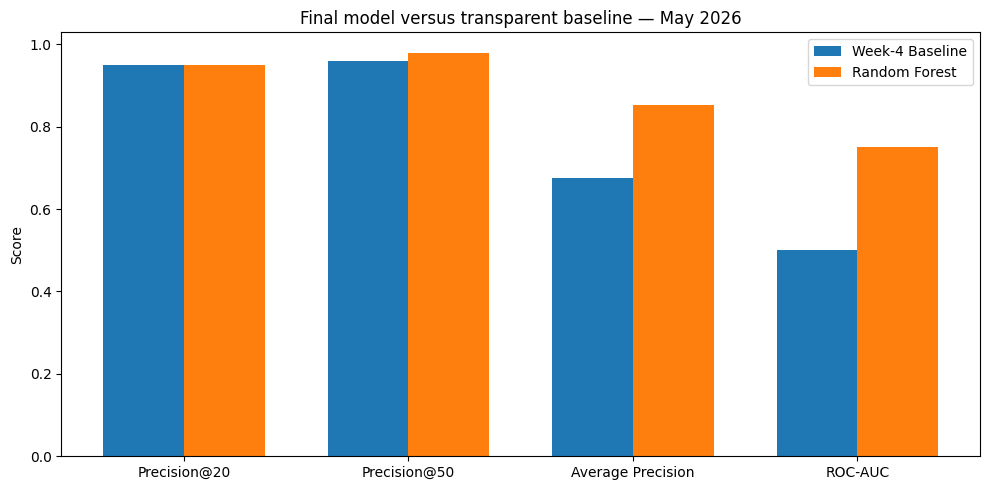

Saved: work/outputs/model_vs_baseline.png


In [53]:
# ============================================================
# Artifact 1 — Model vs baseline
# ============================================================

chart_metrics = [
    "precision_at_20",
    "precision_at_50",
    "average_precision",
    "roc_auc",
]

chart_labels = [
    "Precision@20",
    "Precision@50",
    "Average Precision",
    "ROC-AUC",
]

baseline_values = [
    sealed_baseline_results[m]
    for m in chart_metrics
]

model_values = [
    sealed_results[m]
    for m in chart_metrics
]

x = np.arange(len(chart_labels))
width = 0.36

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Week-4 Baseline"
)

plt.bar(
    x + width / 2,
    model_values,
    width,
    label="Random Forest"
)

plt.xticks(
    x,
    chart_labels
)

plt.ylabel("Score")
plt.title("Final model versus transparent baseline — May 2026")
plt.legend()

plt.tight_layout()

baseline_model_chart = (
    output_dir /
    "model_vs_baseline.png"
)

plt.savefig(
    baseline_model_chart,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Saved:", baseline_model_chart)

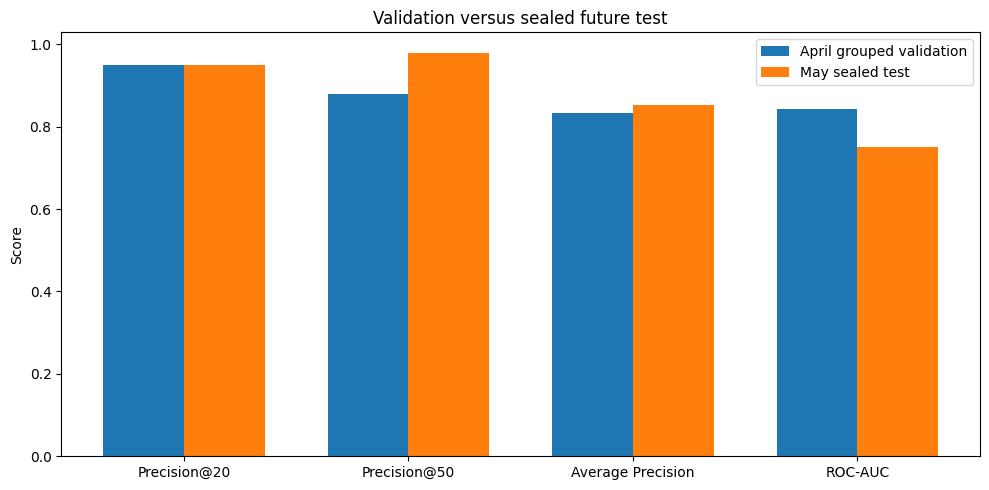

Saved: work/outputs/validation_vs_sealed_test.png


In [54]:
# ============================================================
# Artifact 2 — Validation vs sealed test
# ============================================================

period_metrics = [
    "precision_at_20",
    "precision_at_50",
    "average_precision",
    "roc_auc",
]

period_labels = [
    "Precision@20",
    "Precision@50",
    "Average Precision",
    "ROC-AUC",
]

validation_values = [
    grouped_results[m]
    for m in period_metrics
]

test_values = [
    sealed_results[m]
    for m in period_metrics
]

x = np.arange(len(period_labels))
width = 0.36

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    validation_values,
    width,
    label="April grouped validation"
)

plt.bar(
    x + width / 2,
    test_values,
    width,
    label="May sealed test"
)

plt.xticks(
    x,
    period_labels
)

plt.ylabel("Score")
plt.title("Validation versus sealed future test")

plt.legend()

plt.tight_layout()

validation_test_chart = (
    output_dir /
    "validation_vs_sealed_test.png"
)

plt.savefig(
    validation_test_chart,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Saved:", validation_test_chart)

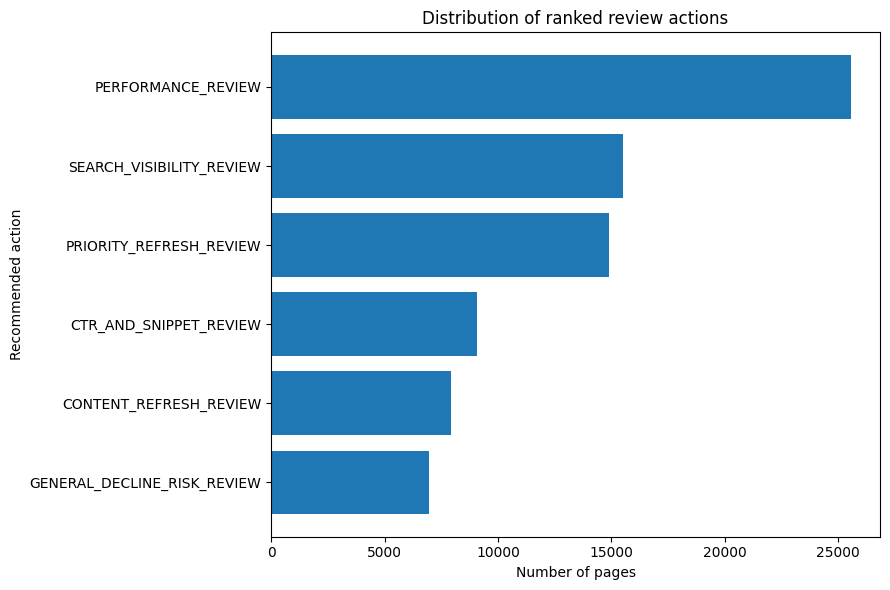

Saved: work/outputs/recommendation_distribution.png


In [55]:
# ============================================================
# Artifact 4 — Recommendation distribution
# ============================================================

plot_actions = (
    recommendations["action"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_actions.index,
    plot_actions.values
)

plt.xlabel("Number of pages")
plt.ylabel("Recommended action")
plt.title("Distribution of ranked review actions")

plt.tight_layout()

recommendation_chart = (
    output_dir /
    "recommendation_distribution.png"
)

plt.savefig(
    recommendation_chart,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Saved:", recommendation_chart)

In [56]:
# ============================================================
# Final metrics receipt
# ============================================================

metrics_receipt = {
    "release": RELEASE_ID,

    "feature_window_days": FEATURE_DAYS,
    "target_window_days": TARGET_DAYS,
    "decline_threshold": DECLINE_THRESHOLD,

    "training_dates": [
        d.strftime("%Y-%m-%d")
        for d in TRAIN_DATES
    ],

    "validation_date": (
        VALIDATION_DATE.strftime("%Y-%m-%d")
    ),

    "sealed_test_date": (
        TEST_DATE.strftime("%Y-%m-%d")
    ),

    "validation": grouped_results,

    "sealed_test": sealed_results,

    "sealed_baseline": sealed_baseline_results,

    "random_seed": RANDOM_SEED,
}

metrics_path = (
    output_dir /
    "capstone_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2,
        default=str
    )

print(
    "Saved:",
    metrics_path
)

Saved: work/outputs/capstone_metrics.json


## 9. Acknowledgments & data credit

Built on the FlyRank ML Internship dataset. Data credit: [FlyRank](https://flyrank.ai).

# ML-12 — 5-Minute Demo

### 0:00–0:45 — The problem

I wanted to answer:

> Can information available before a decision date be used to rank pages that are likely to experience a meaningful future decline, so a content team can review the highest-risk pages first?

The unit of analysis is one content page at one decision date.

### 0:45–1:30 — The data

I used the pseudonymized FlyRank warehouse release with pre-decision search and content-performance signals.

The model uses a 90-day feature window and predicts a 30-day future decline.

Outcome-derived fields were excluded to prevent leakage.

### 1:30–2:15 — The baseline

I first created a transparent Week-4 rule based on stale and visible pages.

This gives a simple benchmark that a human can understand without ML.

### 2:15–3:15 — The model and validation

I compared Logistic Regression and Random Forest.

An initial time-based validation produced an unusually strong result, but inspection showed client concentration in the top-ranked pages.

I therefore added an unseen-client validation check.

The Random Forest achieved:

- Precision@20 = 0.95
- Precision@50 = 0.88
- Average Precision = 0.833
- ROC-AUC = 0.842

### 3:15–4:15 — Sealed test

The final model was retrained using February through April and evaluated once on the sealed May period.

On May:

- Random Forest Precision@20 = 0.95
- Random Forest Precision@50 = 0.98
- Random Forest Average Precision = 0.852
- Random Forest ROC-AUC = 0.751

The baseline also achieved Precision@20 = 0.95, so the main advantage of the model was broader ranking discrimination rather than the first 20 pages alone.

### 4:15–5:00 — Recommendation engine

The final output is a ranked review queue with:

- risk score
- rank
- reason code
- recommended action
- priority band

The output is intended as decision-support for human content review, not an automated editorial decision.

### Closing statement

The main finding is that a learned model can improve the ordering of future-decline risk beyond a simple transparent rule, while the top of the queue remains competitive with the baseline. The result is directional and observational rather than causal.

## Social-post cut

I built a small ML system for Search Intelligence using the FlyRank pseudonymized warehouse.

The question was simple: can pre-decision search and content signals help rank pages that are likely to experience a meaningful future decline?

I started with a transparent stale × visible baseline, then compared Logistic Regression and Random Forest with leakage checks, time-aware evaluation, and an unseen-client validation audit.

On the sealed May test, the Random Forest matched the baseline at Precision@20 (0.95) and improved Precision@50 (0.98 vs 0.96), Average Precision (0.852 vs 0.675), and ROC-AUC (0.751 vs 0.500).

The result is not a prediction of Google's algorithm or proof that refreshing a page will cause recovery. It is a decision-support ranking system that helps a content team decide which pages are worth reviewing first.

## 3-Sentence Employer-Facing Summary

I built and evaluated a leakage-controlled ML ranking system that uses pre-decision search and content signals to prioritize pages at risk of a defined 30-day future decline.

The system combines a transparent rule baseline with Random Forest modeling, time-aware evaluation, an unseen-client validation audit, and a sealed future test; on May 2026 it achieved 0.852 average precision and 0.751 ROC-AUC compared with 0.675 and 0.500 for the baseline.

The final system converts model scores into a ranked review queue with reason codes and human-action recommendations, while explicitly treating the result as observational decision-support rather than causal prediction.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
